# 44. Polynomial Interpolation and Its Five Forms

**Part 7: Interpolation**

## Learning objectives

By the end of this lesson you will be able to:

1. State and prove the **existence and uniqueness** theorem for polynomial interpolation.
2. Write the same polynomial in **five different forms** and verify they agree.
3. Say why the **power form** is almost never used, and measure the reason.
4. Use the **Newton form**, and exploit the one property no other form has.
5. Rearrange the **Lagrange form** into the barycentric one, and say what that buys.
6. Choose the right form for a given task, from cost and conditioning rather than habit.

## Prerequisites

Lesson 5 (Horner evaluation and nested forms). Lesson 15 (condition numbers, which the
Vandermonde matrix will supply a spectacular example of). Lesson 17 (why a linear solve can lose
digits). Lesson 29 (the normal equations, whose conditioning problem this lesson repeats in a
different costume).

---

## 1. The theorem, and what it does not say

**Given $n+1$ points with distinct abscissas, there is exactly one polynomial of degree at most
$n$ through them.**

The proof is two lines in each direction. For **existence**, write the Lagrange form of section 5
and check it works. For **uniqueness**, suppose $p$ and $q$ both do it. Then $p - q$ is a
polynomial of degree at most $n$ with $n+1$ roots, so it is the zero polynomial.

That is the whole theorem, and it is worth being precise about what it leaves open. It says the
polynomial exists and is unique. It says nothing about:

- how to **write it down**, and there are at least five ways;
- how to **compute** its coefficients, and the ways differ by fourteen orders of magnitude in
  accuracy;
- whether it is **any good** as an approximation, which is lesson 46's subject and often it is
  not.

This lesson is about the second point. Lesson 46 is about the third.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import interp as ip

x_demo = np.linspace(-1.0, 1.0, 8)
y_demo = np.cos(3.0 * x_demo)

report = ip.uniqueness_report(x_demo, y_demo, n_trials=6, rng=rng)
print(f"kappa(Vandermonde) = {report['vandermonde_kappa']:.3e}")
print()
print("the same polynomial, five ways, at six random points:")
for name, gap in report["max_disagreement"].items():
    print(f"  {name:>16}: max relative disagreement {gap:.2e}")
assert all(gap < 1e-10 for gap in report["max_disagreement"].values())

kappa(Vandermonde) = 5.354e+02

the same polynomial, five ways, at six random points:
             power: max relative disagreement 1.72e-15
     shifted power: max relative disagreement 1.05e-15
            newton: max relative disagreement 1.55e-15
          lagrange: max relative disagreement 5.55e-16
       barycentric: max relative disagreement 0.00e+00


Five constructions, one polynomial. That is the theorem made visible, and every form below is a
different way of writing the same object.

## 2. The power form, and why not

The obvious representation is $p(t) = \sum_k a_k t^k$. Finding the $a_k$ means solving

$$
\begin{pmatrix}
1 & x_0 & x_0^2 & \cdots & x_0^n \\
1 & x_1 & x_1^2 & \cdots & x_1^n \\
\vdots & & & & \vdots \\
1 & x_n & x_n^2 & \cdots & x_n^n
\end{pmatrix}
\begin{pmatrix} a_0 \\ a_1 \\ \vdots \\ a_n \end{pmatrix}
=
\begin{pmatrix} y_0 \\ y_1 \\ \vdots \\ y_n \end{pmatrix}
$$

the **Vandermonde system**. It is nonsingular whenever the nodes are distinct, since its
determinant is $\prod_{i<j}(x_j - x_i)$, so the theorem is proved a third time. And it is a
catastrophe to compute with.

In [3]:
print("kappa(V) for equally spaced nodes on [-1, 1]:")
for n in (5, 10, 15, 20, 25, 30):
    nodes = np.linspace(-1.0, 1.0, n)
    print(f"  n = {n:>3}:  kappa = {ip.vandermonde_condition(nodes):.3e}")

kappa(V) for equally spaced nodes on [-1, 1]:
  n =   5:  kappa = 2.353e+01
  n =  10:  kappa = 4.626e+03
  n =  15:  kappa = 1.105e+06
  n =  20:  kappa = 2.722e+08
  n =  25:  kappa = 7.053e+10
  n =  30:  kappa = 1.839e+13


The growth is **exponential in $n$**, and by 30 nodes the condition number is $1.8\times10^{13}$,
so the computed coefficients have about three correct digits.

The reason is structural, not accidental. On a fixed interval the functions $1, t, t^2, t^3,
\dots$ all look increasingly alike: they are all near zero in the middle and all rise steeply at
the ends. The columns of $V$ are samples of nearly parallel functions, so $V$ is nearly singular
by construction. Lesson 29 met the same phenomenon in the normal equations, and the cure there,
as here, is to stop forming the bad object.

## 3. Shifting, and then scaling

The first repair is cheap. Expand about a centre $c$ instead of about zero:

$$
p(t) = \sum_k a_k (t - c)^k
$$

which is the same polynomial with different coefficients. Taking $c$ near the data stops the high
powers from all having the same sign and similar magnitude.

In [4]:
print(f"{'interval':>20}{'raw':>13}{'centred':>13}{'centred+scaled':>17}")
for lo, hi in ((-1.0, 1.0), (0.0, 1.0), (99.0, 101.0), (-0.001, 0.001), (1e6, 1e6 + 1)):
    nodes = np.linspace(lo, hi, 13)
    centre = float(np.mean(nodes))
    half = 0.5 * (float(np.max(nodes)) - float(np.min(nodes)))
    print(f"{f'[{lo:g}, {hi:g}]':>20}"
          f"{ip.vandermonde_condition(nodes):>13.2e}"
          f"{ip.vandermonde_condition(nodes - centre):>13.2e}"
          f"{ip.vandermonde_condition((nodes - centre) / half):>17.2e}")

            interval          raw      centred   centred+scaled
             [-1, 1]     1.23e+05     1.23e+05         1.23e+05
              [0, 1]     6.78e+09     1.31e+08         1.23e+05
           [99, 101]     3.07e+37     1.23e+05         1.23e+05
     [-0.001, 0.001]     2.69e+40     2.69e+40         1.23e+05
      [1e+06, 1e+06]     1.78e+88     1.31e+08         1.23e+05


Two lessons in one table.

**Shifting fixes an interval far from the origin and nothing else.** At $[99, 101]$ it takes
$\kappa$ from $3.1\times10^{37}$ to $1.2\times10^5$. At $[-0.001, 0.001]$ it changes nothing,
because the trouble there is the *scale*, not the offset.

**Shifting and scaling together fix everything.** Mapping the nodes to $[-1, 1]$ gives
$\kappa = 1.2\times10^5$ in **every** row. The conditioning becomes a property of the degree
alone, which is the intrinsic part, and that residual $1.2\times10^5$ is what no change of
variable can remove.

This is why `numpy.polynomial.Polynomial` carries a `domain` and a `window` and maps between them.
It is not bookkeeping, it is thirty orders of magnitude.

In [5]:
bad_nodes = np.linspace(999.0, 1001.0, 12)
try:
    ip.power_form(bad_nodes, np.sin(bad_nodes))
except np.linalg.LinAlgError as exc:
    print("power_form refuses, and says why:")
    print(" ", str(exc))

power_form refuses, and says why:
  the Vandermonde matrix on these 12 nodes is numerically singular, kappa = 4.50e+47. Centring the nodes on their mean gives kappa = 4.08e+04, so use shifted_power_form, or better a Newton or barycentric form, which never build this matrix at all


## 4. The Newton form and its one advantage

Write the polynomial as

$$
p(t) = c_0 + c_1(t - x_0) + c_2(t - x_0)(t - x_1) + \cdots + c_n\prod_{i<n}(t - x_i)
$$

The coefficients are the **divided differences**, which lesson 45 develops. Evaluation is a
nested loop costing $n$ multiplications, exactly like Horner's rule.

The advantage that no other form has is this:

In [6]:
nodes = np.linspace(0.0, 1.0, 5)
coeffs = ip.newton_coefficients(nodes, np.exp(nodes))
print("coefficients on 5 nodes:")
print(" ", np.array2string(coeffs, precision=8))

extra = 1.3
coeffs2, nodes2 = ip.newton_add_point(coeffs, nodes, extra, float(np.exp(extra)))
print(f"\nafter adding a sixth point at t = {extra}:")
print(" ", np.array2string(coeffs2, precision=8))
print(f"\nthe first five are bit for bit identical: {np.array_equal(coeffs, coeffs2[:coeffs.size])}")
assert np.array_equal(coeffs, coeffs2[:coeffs.size])
print(f"the new point is interpolated to "
      f"{abs(float(ip.evaluate_newton(coeffs2, nodes2, extra)) - float(np.exp(extra))):.2e}")

coefficients on 5 nodes:
  [1.         1.13610167 0.6453635  0.24439952 0.06941567]

after adding a sixth point at t = 1.3:
  [1.         1.13610167 0.6453635  0.24439952 0.06941567 0.01591742]

the first five are bit for bit identical: True
the new point is interpolated to 0.00e+00


**Adding a point costs $O(n)$ and changes nothing already computed.** Every other form has to be
rebuilt from scratch, at $O(n^2)$ or worse. That is why an adaptive scheme, which adds points
until some tolerance is met, carries the Newton form.

The price is that the coefficients depend on the **order** of the nodes, even though the
polynomial does not.

In [7]:
shuffled = rng.permutation(nodes)
reordered = ip.change_of_centre(coeffs, nodes, shuffled)
probe = np.linspace(0.0, 1.0, 7)
a = ip.evaluate_newton(coeffs, nodes, probe)
b = ip.evaluate_newton(reordered, shuffled, probe)
print(f"different coefficients: {not np.allclose(coeffs, reordered)}")
print(f"same polynomial to {float(np.max(np.abs(a - b))):.2e}")
assert not np.allclose(coeffs, reordered) and float(np.max(np.abs(a - b))) < 1e-10

different coefficients: True
same polynomial to 0.00e+00


## 5. Lagrange, and the rearrangement that saves it

The Lagrange form solves nothing at all:

$$
p(t) = \sum_i y_i L_i(t), \qquad L_i(t) = \prod_{j \ne i}\frac{t - x_j}{x_i - x_j}
$$

Each $L_i$ is 1 at $x_i$ and 0 at every other node, so the coefficients **are** the data. That is
the appeal, and it is why the Lagrange form is the one used in proofs.

Written that way it is also poor: each evaluation costs $O(n^2)$, and the products can overflow.
Rearranging fixes both. Define the **barycentric weights**

$$
w_i = \frac{1}{\prod_{j\ne i}(x_i - x_j)}
$$

which depend only on the nodes. Then a little algebra gives the **second barycentric formula**

$$
p(t) = \frac{\sum_i \dfrac{w_i\,y_i}{t - x_i}}{\sum_i \dfrac{w_i}{t - x_i}}
$$

In [8]:
sizes = (5, 10, 20, 40)
print(f"{'n':>5}{'lagrange naive':>17}{'barycentric':>14}{'ratio':>9}")
for n in sizes:
    cost = ip.interpolation_cost(n)
    print(f"{n:>5}{cost['lagrange_naive']:>17}{cost['barycentric']:>14}"
          f"{cost['lagrange_naive'] / cost['barycentric']:>8.1f}x")

    n   lagrange naive   barycentric    ratio
    5               50            25     2.0x
   10              200            50     4.0x
   20              800           100     8.0x
   40             3200           200    16.0x


The weights cost $O(n^2)$ once, and every evaluation afterwards costs $O(n)$. For interpolating
at many points on a fixed grid, which is the usual case, that is the whole cost.

There is a second, less obvious gain. Higham proved the barycentric formula **backward stable**,
which the naive Lagrange form is not. And it has a property worth measuring:

In [9]:
nodes_b = np.linspace(-1.0, 1.0, 21)
values_b = rng.standard_normal(nodes_b.size)
at_nodes = ip.evaluate_barycentric(nodes_b, values_b, nodes_b)
print(f"barycentric at its own nodes, largest error: "
      f"{float(np.max(np.abs(at_nodes - values_b))):.1e}")
newton_c = ip.newton_coefficients(nodes_b, values_b)
at_nodes_n = ip.evaluate_newton(newton_c, nodes_b, nodes_b)
print(f"newton at its own nodes, largest error:      "
      f"{float(np.max(np.abs(at_nodes_n - values_b))):.1e}")
print(f"kappa of the normalised Vandermonde here:    {ip.vandermonde_condition(nodes_b):.1e}")
assert np.array_equal(at_nodes, values_b)
assert float(np.max(np.abs(at_nodes_n - values_b))) > 0.0

barycentric at its own nodes, largest error: 0.0e+00
newton at its own nodes, largest error:      4.5e-08
kappa of the normalised Vandermonde here:    8.3e+08


The barycentric formula reproduces the data **exactly**, at every degree, because the formula
contains a factor that is exactly zero at a node and the special case returns the data value
untouched. The coefficient based forms reproduce it to $\varepsilon\,\kappa$, which is a real and
growing error.

## 6. Choosing

In [10]:
print(f"{'situation':>44}  {'form'}")
print(f"{'-' * 44}  {'-' * 26}")
for situation, form in (
        ("evaluating at many points on fixed nodes", "barycentric Lagrange"),
        ("points arriving one at a time", "Newton"),
        ("you need the coefficients themselves", "normalised power form"),
        ("writing a proof", "Lagrange"),
        ("nodes equally spaced, working by hand", "Newton, as lesson 49 rearranges it"),
        ("degree above about 20", "none of them, see lesson 46")):
    print(f"{situation:>44}  {form}")

                                   situation  form
--------------------------------------------  --------------------------
    evaluating at many points on fixed nodes  barycentric Lagrange
               points arriving one at a time  Newton
        you need the coefficients themselves  normalised power form
                             writing a proof  Lagrange
       nodes equally spaced, working by hand  Newton, as lesson 49 rearranges it
                       degree above about 20  none of them, see lesson 46


The last row is not a joke. Everything in this lesson is about writing down a polynomial that
passes through the data. Lesson 46 asks whether you should want one, and for equally spaced nodes
above about twenty the answer is no.

## 7. A picture

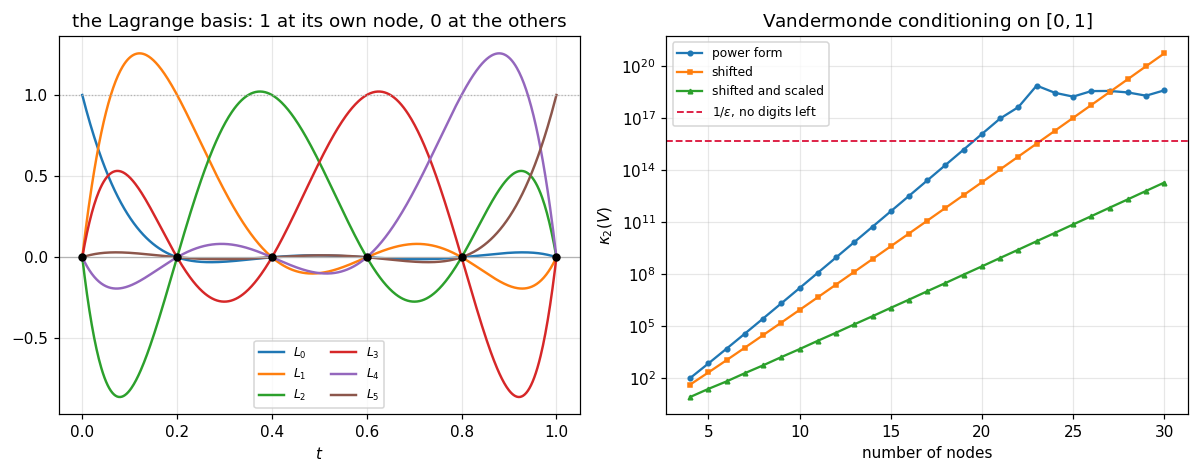

In [11]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

# left: the Lagrange basis, which is where the coefficients "are the data" comes from
basis_nodes = np.linspace(0.0, 1.0, 6)
fine = np.linspace(0.0, 1.0, 600)
basis = ip.lagrange_basis(basis_nodes, fine)
for i in range(basis_nodes.size):
    ax_left.plot(fine, basis[i], lw=1.6, label=f"$L_{i}$")
ax_left.plot(basis_nodes, np.zeros_like(basis_nodes), "k.", ms=9, zorder=5)
ax_left.axhline(0.0, color="0.7", lw=0.8)
ax_left.axhline(1.0, color="0.7", lw=0.8, ls=":")
ax_left.set_title("the Lagrange basis: 1 at its own node, 0 at the others")
ax_left.set_xlabel("$t$")
ax_left.legend(fontsize=8, ncol=2)

# right: the conditioning of the three power forms
counts = np.arange(4, 31)
raw, centred, scaled = [], [], []
for n in counts:
    nd = np.linspace(0.0, 1.0, n)
    c = float(np.mean(nd))
    half = 0.5 * (float(np.max(nd)) - float(np.min(nd)))
    raw.append(ip.vandermonde_condition(nd))
    centred.append(ip.vandermonde_condition(nd - c))
    scaled.append(ip.vandermonde_condition((nd - c) / half))
ax_right.semilogy(counts, raw, "o-", ms=3, label="power form")
ax_right.semilogy(counts, centred, "s-", ms=3, label="shifted")
ax_right.semilogy(counts, scaled, "^-", ms=3, label="shifted and scaled")
ax_right.axhline(1.0 / np.finfo(float).eps, color="crimson", ls="--", lw=1.2,
                 label=r"$1/\varepsilon$, no digits left")
ax_right.set_title("Vandermonde conditioning on $[0, 1]$")
ax_right.set_xlabel("number of nodes")
ax_right.set_ylabel(r"$\kappa_2(V)$")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel is why the Lagrange form is the one in every proof. The right panel is why it is
not the one in any program: even after shifting and scaling, the conditioning crosses
$1/\varepsilon$ before thirty nodes, so the coefficients of a degree 30 polynomial cannot be
computed at all in double precision, in any of these bases.

## 8. Exercises

**Level 1, conceptual**

1.1 The uniqueness theorem is proved three times in this lesson, by three different arguments.
Name them, and say which one also gives an algorithm.

1.2 A colleague reports that their interpolating polynomial "does not pass through the data" at
30 nodes. Give the two most likely causes and the one measurement that distinguishes them.

1.3 The barycentric formula divides by $t - x_i$, which is zero at a node. Explain why that is
not a defect, and what the code must do about it.

**Level 2, mathematical**

2.1 Prove existence and uniqueness of the interpolating polynomial, both directions, and identify
exactly where distinctness of the nodes is used in each.

2.2 Derive the second barycentric formula from the Lagrange form, and explain why the constant
$\prod_j (t - x_j)$ cancels.

2.3 Show that the Vandermonde determinant is $\prod_{i<j}(x_j - x_i)$, and use it to give a third
proof of uniqueness.

2.4 Prove that the Newton coefficients are unchanged when a node is appended, and count the
operations that saves against rebuilding.

2.5 Show that the barycentric weights are defined only up to a common factor, and that the second
barycentric formula is invariant to that factor. Say what this buys computationally.

**Level 3, computational**

3.1 Implement **Neville's algorithm**, which evaluates the interpolating polynomial by a tableau
of repeated linear interpolations without ever forming coefficients. Compare its cost and
accuracy against the barycentric form.

3.2 Implement the **modified Lagrange (first barycentric)** formula and measure it against the
second one, including outside the interval where the two behave differently.

3.3 Implement interpolation in the **Bernstein basis** of lesson 52 and measure its conditioning
against the power, shifted power and normalised forms.

**Level 4, experimental**

4.1 Measure the growth of $\kappa(V)$ against $n$ for equally spaced, Chebyshev and random nodes,
fit each, and identify which node family gives the slowest growth.

4.2 Measure the accuracy of all five forms at their own nodes against the degree, and fit the
relationship to $\varepsilon\,\kappa$.

4.3 Measure the cost of setup and of evaluation separately for each form, find the number of
evaluation points at which each becomes the cheapest, and explain the crossovers.

**Level 5, advanced**

5.1 **Why the barycentric formula is stable and the Lagrange form is not.** State Higham's result
precisely, identify the step in the naive form where stability is lost, and construct data on
which the difference is visible.

5.2 **Interpolation as a linear operator.** The map from data to polynomial is linear, so it has
a norm. Identify that norm, relate it to lesson 47's Lebesgue constant, and explain what it says
about the whole subject.

5.3 **The Vandermonde matrix is not the only bad basis, and there is a good one.** Explain what
makes a polynomial basis well conditioned on an interval, name a basis that is, and measure its
conditioning against the power form.

## 9. Key takeaways

- **Exactly one polynomial** of degree at most $n$ passes through $n+1$ points with distinct
  abscissas. Existence and uniqueness are both easy; everything hard is downstream.

- **Five forms, one polynomial.** Power, shifted power, Newton, Lagrange and barycentric all
  represent the same object and were measured to agree.

- **The power form is unusable above about 20 nodes**, and the reason is the Vandermonde
  conditioning, which grows exponentially: $2.4\times10^1$ at 5 nodes and $1.8\times10^{13}$ at 30.

- **Shifting fixes an offset and scaling fixes a scale.** Doing both maps the nodes to $[-1,1]$
  and makes $\kappa$ the same $1.2\times10^5$ whether the data sits on $[-1,1]$, on
  $[10^6, 10^6+1]$ or on $[-0.001, 0.001]$.

- **The Newton form is the one that grows.** Adding a point costs $O(n)$ and leaves every existing
  coefficient bit for bit unchanged.

- **The barycentric form is the one that evaluates.** $O(n)$ per point after an $O(n^2)$ setup,
  backward stable, and exact at its own nodes at every degree.

- **None of this makes high degree interpolation a good idea.** That is lesson 46.

## Where this goes next

Lesson 45 develops the divided differences that the Newton form's coefficients are, and finds
that they lose all their accuracy by about order 13. Lesson 46 asks whether the interpolating
polynomial is any good, and shows it can diverge on a perfectly smooth function. Lesson 47 fixes
that by moving the nodes. Lessons 50 and 51 give up on high degree entirely, which turns out to
be the answer.